# CS3807 — Deep Learning Laboratory — Experiment 6
## End-to-End Study of RNN, LSTM and GRU for Sequence Learning and Video Understanding

This notebook is structured so that **every expensive step (training, feature extraction, downloads) is checkpointed**.
Re-running the notebook, or restarting the kernel, will **resume from the last completed step** instead of starting over.

**How resuming works:**
- Every training run writes its Keras model, an epoch-by-epoch CSV log, and a `*_DONE.flag` file to `checkpoints/`.
- If a `*_DONE.flag` file exists, that step is loaded from disk and **not retrained**.
- If training was interrupted mid-way, the model + log are reloaded and training resumes from `initial_epoch = last logged epoch`, not epoch 0.
- To force a clean re-run of any step, pass `force=True` to the relevant call, or delete the corresponding files in `checkpoints/`.

Run cells top to bottom. Sections are independent enough that you can also jump straight to a later section
(e.g. Section 8, video understanding) as long as the earlier checkpointed artifacts already exist on disk.

## 0. Imports, Global Config and Plot Style

In [1]:
import os
import io
import json
import time
import glob
import shutil
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPU available:", gpus)

# Let TF grow GPU memory instead of grabbing it all up front (avoids OOM crashes
# when other processes / notebooks are also using the GPU).
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except RuntimeError as e:
        print("Could not set memory growth:", e)

# Mixed precision gives a meaningful speedup on modern NVIDIA GPUs (Volta+) and
# is a safe no-op on CPU-only machines, so we enable it opportunistically.
if gpus:
    try:
        keras.mixed_precision.set_global_policy("mixed_float16")
        print("Mixed precision enabled (mixed_float16).")
    except Exception as e:
        print("Mixed precision not enabled:", e)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

C:\Users\Harshini J\AppData\Local\Programs\Python\Python312\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.2) or chardet (7.4.3)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


TensorFlow version: 2.19.0
GPU available: []


In [2]:
# ------------------------------------------------------------
# Publication-style plot formatting (bold serif, EPS @ 600 dpi)
# ------------------------------------------------------------

os.makedirs("images", exist_ok=True)

available_fonts = {f.name for f in font_manager.fontManager.ttflist}
if "Times New Roman" in available_fonts:
    serif_font = "Times New Roman"
elif "Liberation Serif" in available_fonts:
    serif_font = "Liberation Serif"
else:
    serif_font = "DejaVu Serif"
print(f"Using font: {serif_font}")

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": [serif_font],
    "font.weight": "bold",
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.labelsize": 14,
    "axes.labelweight": "bold",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "figure.figsize": (8, 6),
    "savefig.dpi": 600,
    "savefig.format": "eps",
    "savefig.bbox": "tight",
})

def make_bold_ticks(ax):
    for label in ax.get_xticklabels():
        label.set_fontweight("bold")
    for label in ax.get_yticklabels():
        label.set_fontweight("bold")

def save_figure(name):
    ax = plt.gca()
    make_bold_ticks(ax)
    plt.savefig(f"images/{name}.eps", format="eps", dpi=600, bbox_inches="tight")
    # Also save a PNG copy — EPS cannot be inlined by most notebook viewers,
    # so PNG is what you'll actually see rendered below each cell / in Word.
    plt.savefig(f"images/{name}.png", format="png", dpi=200, bbox_inches="tight")

Using font: Times New Roman


In [3]:
# ------------------------------------------------------------
# Directories + generic checkpoint utilities
# ------------------------------------------------------------

CKPT_DIR = "checkpoints"
RESULTS_DIR = "results"
DATA_DIR = "data"
IMAGES_DIR = "images"
for d in [CKPT_DIR, RESULTS_DIR, DATA_DIR, IMAGES_DIR]:
    os.makedirs(d, exist_ok=True)

def ckpt_paths(name):
    """All checkpoint artifact paths for a given run name."""
    return {
        "model":   f"{CKPT_DIR}/{name}_model.keras",
        "log":     f"{CKPT_DIR}/{name}_log.csv",
        "history": f"{CKPT_DIR}/{name}_history.json",
        "time":    f"{CKPT_DIR}/{name}_time.json",
        "done":    f"{CKPT_DIR}/{name}_DONE.flag",
    }

def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f)

def load_json(path, default=None):
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return default

def result_cache_path(name):
    return f"{RESULTS_DIR}/{name}.json"

def cached_result(name, compute_fn, force=False):
    """Generic memoization to disk for anything cheap to serialize as JSON
    (metrics dicts, tables, etc.) — avoids recomputation on re-run."""
    path = result_cache_path(name)
    if os.path.exists(path) and not force:
        return load_json(path)
    result = compute_fn()
    save_json(result, path)
    return result

## 1. Dataset: UCI Human Activity Recognition Using Smartphones

We use the **raw inertial signal files** (not the pre-computed 561-feature vectors), so that the
recurrent models genuinely learn temporal structure from `X ∈ R^(N×128×9)` sequences:
body acceleration (3 axes), body gyroscope (3 axes), and total acceleration (3 axes).

The download + extraction is cached: if `data/UCI_HAR_Dataset/` already exists, nothing is re-downloaded.

In [4]:
HAR_URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
HAR_ZIP = f"{DATA_DIR}/har.zip"
HAR_ROOT = f"{DATA_DIR}/UCI_HAR_Dataset"

def download_har(force=False):
    """Download + extract the UCI HAR dataset, with caching and basic retry logic."""
    inner_zip_candidates = glob.glob(f"{HAR_ROOT}/**/UCI HAR Dataset.zip", recursive=True)
    already_extracted = glob.glob(f"{HAR_ROOT}/**/Inertial Signals", recursive=True)

    if already_extracted and not force:
        print("HAR dataset already extracted — skipping download.")
        return

    os.makedirs(HAR_ROOT, exist_ok=True)

    if not os.path.exists(HAR_ZIP) or force:
        print("Downloading UCI HAR dataset (~58 MB)...")
        last_err = None
        for attempt in range(3):
            try:
                urllib.request.urlretrieve(HAR_URL, HAR_ZIP)
                break
            except Exception as e:
                last_err = e
                print(f"  attempt {attempt+1} failed: {e}")
                time.sleep(2)
        else:
            raise RuntimeError(
                f"Could not download UCI HAR dataset after 3 attempts: {last_err}\n"
                f"If your network blocks archive.ics.uci.edu, download the zip manually from\n"
                f"{HAR_URL}\nand place it at '{HAR_ZIP}', then re-run this cell."
            )

    print("Extracting outer zip...")
    with zipfile.ZipFile(HAR_ZIP) as z:
        z.extractall(HAR_ROOT)

    # The archive nests a second zip ("UCI HAR Dataset.zip") inside the outer one.
    inner_zip_candidates = glob.glob(f"{HAR_ROOT}/**/*.zip", recursive=True)
    for inner in inner_zip_candidates:
        print("Extracting inner zip:", inner)
        with zipfile.ZipFile(inner) as z:
            z.extractall(os.path.dirname(inner))

    found = glob.glob(f"{HAR_ROOT}/**/Inertial Signals", recursive=True)
    if not found:
        raise RuntimeError(
            "Extraction finished but 'Inertial Signals' folders were not found. "
            "The dataset layout may have changed upstream — inspect data/UCI_HAR_Dataset manually."
        )
    print(f"HAR dataset ready. Found {len(found)} 'Inertial Signals' directories.")

download_har()

HAR dataset already extracted — skipping download.


In [5]:
def find_har_split_dir(split):
    """Locate the train/ or test/ directory regardless of exact nesting depth."""
    candidates = glob.glob(f"{HAR_ROOT}/**/{split}", recursive=True)
    candidates = [c for c in candidates if os.path.isdir(os.path.join(c, "Inertial Signals"))]
    if not candidates:
        raise FileNotFoundError(f"Could not locate a '{split}' directory with Inertial Signals under {HAR_ROOT}")
    return candidates[0]

SIGNAL_NAMES = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]
ACTIVITY_NAMES = {
    1: "WALKING", 2: "WALKING_UPSTAIRS", 3: "WALKING_DOWNSTAIRS",
    4: "SITTING", 5: "STANDING", 6: "LAYING",
}

def load_har_split(split):
    """Returns X: (N, 128, 9) float32, y: (N,) int labels in [0, 5]."""
    split_dir = find_har_split_dir(split)
    sig_dir = os.path.join(split_dir, "Inertial Signals")
    prefix = "train" if split == "train" else "test"

    channels = []
    for sig in SIGNAL_NAMES:
        fpath = os.path.join(sig_dir, f"{sig}_{prefix}.txt")
        if not os.path.exists(fpath):
            raise FileNotFoundError(f"Expected signal file not found: {fpath}")
        arr = np.loadtxt(fpath, dtype=np.float32)  # (N, 128)
        channels.append(arr)
    X = np.stack(channels, axis=-1)  # (N, 128, 9)

    y_path = os.path.join(split_dir, f"y_{prefix}.txt")
    y = np.loadtxt(y_path, dtype=np.int64) - 1  # convert 1..6 -> 0..5

    assert X.shape[0] == y.shape[0], "Mismatch between signal rows and label rows."
    assert X.shape[1:] == (128, 9), f"Unexpected window shape {X.shape[1:]}"
    return X, y

X_train_full, y_train_full = load_har_split("train")
X_test_full,  y_test_full  = load_har_split("test")
print("Raw train:", X_train_full.shape, y_train_full.shape)
print("Raw test :", X_test_full.shape,  y_test_full.shape)

Raw train: (7352, 128, 9) (7352,)
Raw test : (2947, 128, 9) (2947,)


In [6]:
# ------------------------------------------------------------
# Recommended laboratory subset: 1500-3000 balanced training windows,
# all 6 classes preserved. We keep the *entire* test set (already small),
# and carve validation out of the subsampled training pool.
# ------------------------------------------------------------

TARGET_TRAIN_POOL = 2400          # within the 1500-3000 recommended range
N_CLASSES = 6
VAL_FRACTION_OF_TRAINVAL = 15 / 85   # 70/15/15 overall -> 15% of (train+val) pool is val

def stratified_subsample(X, y, target_n, seed=SEED):
    rng = np.random.RandomState(seed)
    per_class = target_n // N_CLASSES
    idx_selected = []
    for c in range(N_CLASSES):
        idx_c = np.where(y == c)[0]
        rng.shuffle(idx_c)
        take = min(per_class, len(idx_c))
        idx_selected.append(idx_c[:take])
    idx_selected = np.concatenate(idx_selected)
    rng.shuffle(idx_selected)
    return X[idx_selected], y[idx_selected]

X_pool, y_pool = stratified_subsample(X_train_full, y_train_full, TARGET_TRAIN_POOL)

X_train, X_val, y_train, y_val = train_test_split(
    X_pool, y_pool,
    test_size=VAL_FRACTION_OF_TRAINVAL,
    stratify=y_pool,
    random_state=SEED,
)
X_test, y_test = X_test_full, y_test_full

print("Input tensor shape:")
print(f"  Training   : {X_train.shape}")
print(f"  Validation : {X_val.shape}")
print(f"  Testing    : {X_test.shape}")
print(f"\nNumber of classes: {N_CLASSES}")
print(f"Number of features per time step: {X_train.shape[-1]}")
print(f"Sequence length: {X_train.shape[1]}")

print("\nClass distribution (train / val / test):")
dist = pd.DataFrame({
    "train": pd.Series(y_train).value_counts().sort_index(),
    "val":   pd.Series(y_val).value_counts().sort_index(),
    "test":  pd.Series(y_test).value_counts().sort_index(),
}).fillna(0).astype(int)
dist.index = [ACTIVITY_NAMES[i + 1] for i in dist.index]
print(dist)

Input tensor shape:
  Training   : (1976, 128, 9)
  Validation : (424, 128, 9)
  Testing    : (2947, 128, 9)

Number of classes: 6
Number of features per time step: 9
Sequence length: 128

Class distribution (train / val / test):
                    train  val  test
WALKING               330   70   496
WALKING_UPSTAIRS      330   70   471
WALKING_DOWNSTAIRS    329   71   420
SITTING               329   71   491
STANDING              329   71   532
LAYING                329   71   537


In [7]:
# ------------------------------------------------------------
# Normalization — fit per-channel statistics on the TRAINING data only,
# then apply identically to train/val/test (no leakage).
# ------------------------------------------------------------

def fit_channel_scaler(X):
    # X: (N, T, F) -> flatten time into the sample axis so StandardScaler sees (N*T, F)
    N, T, F = X.shape
    scaler = StandardScaler()
    scaler.fit(X.reshape(-1, F))
    return scaler

def apply_channel_scaler(X, scaler):
    N, T, F = X.shape
    Xs = scaler.transform(X.reshape(-1, F)).reshape(N, T, F)
    return Xs.astype(np.float32)

har_scaler = fit_channel_scaler(X_train)
X_train_n = apply_channel_scaler(X_train, har_scaler)
X_val_n   = apply_channel_scaler(X_val,   har_scaler)
X_test_n  = apply_channel_scaler(X_test,  har_scaler)

print("Post-normalization per-channel mean/std (train):",
      X_train_n.reshape(-1, 9).mean(0).round(3),
      X_train_n.reshape(-1, 9).std(0).round(3))

Post-normalization per-channel mean/std (train): [-0.  0. -0.  0. -0.  0.  0. -0.  0.] [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 2. Temporal Data Visualization (Plot 1)

Sensor signal vs. time step, for three representative channels, across three different activity classes.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


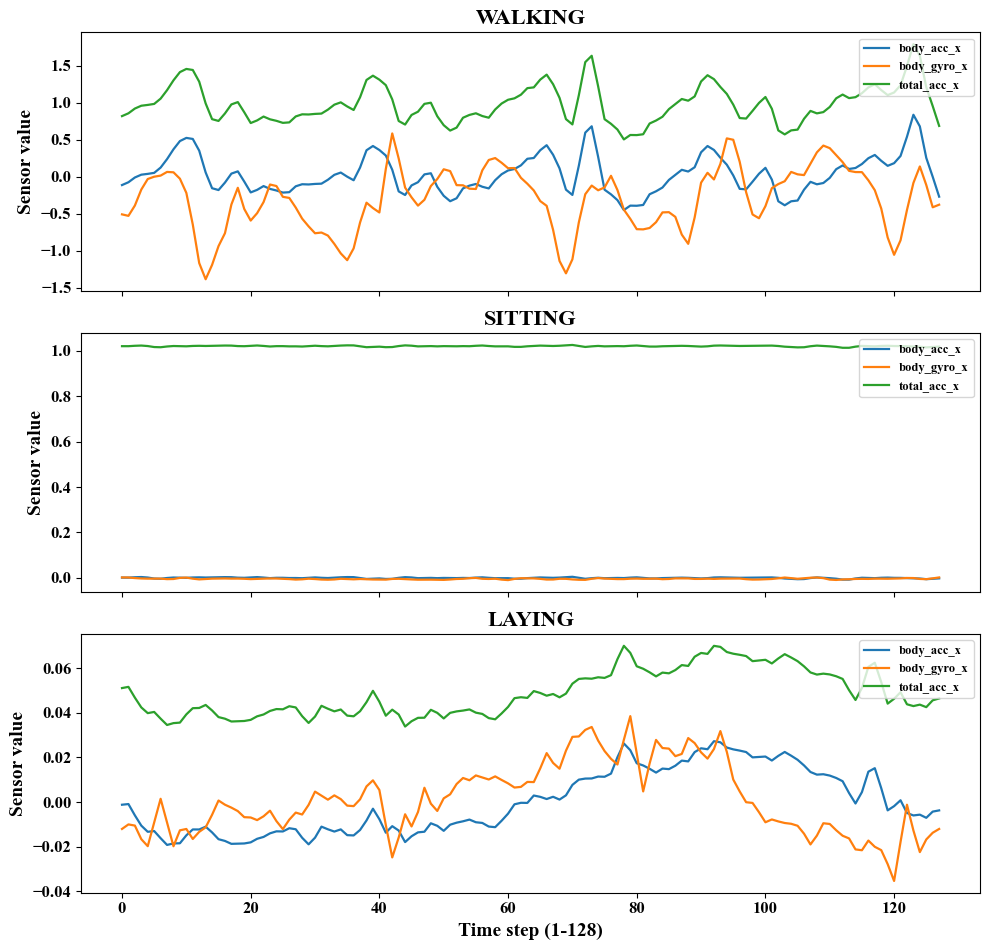

In [8]:
def plot_sequences_for_activities(X, y, activities, channel_idx=(0, 3, 6),
                                   channel_names=("body_acc_x", "body_gyro_x", "total_acc_x")):
    fig, axes = plt.subplots(len(activities), 1, figsize=(10, 3.2 * len(activities)), sharex=True)
    if len(activities) == 1:
        axes = [axes]
    for ax, act in zip(axes, activities):
        idx = np.where(y == act - 1)[0]
        sample_idx = idx[0]
        for ci, cname in zip(channel_idx, channel_names):
            ax.plot(range(X.shape[1]), X[sample_idx, :, ci], label=cname, linewidth=1.6)
        ax.set_title(ACTIVITY_NAMES[act], fontweight="bold")
        ax.set_ylabel("Sensor value")
        ax.legend(loc="upper right", fontsize=9)
        make_bold_ticks(ax)
    axes[-1].set_xlabel("Time step (1-128)")
    plt.tight_layout()
    plt.savefig(f"{IMAGES_DIR}/plot1_temporal_signals.eps", format="eps", dpi=600, bbox_inches="tight")
    plt.savefig(f"{IMAGES_DIR}/plot1_temporal_signals.png", format="png", dpi=200, bbox_inches="tight")
    plt.show()

plot_sequences_for_activities(X_train, y_train, activities=[1, 4, 6])  # WALKING, SITTING, LAYING

**Inference (fill in based on what you observe above):**
1. What temporal pattern is visible?
2. Which activities exhibit similar patterns (e.g. compare the three WALKING variants, or SITTING vs. LAYING)?
3. Why is the ordering of measurements important here — what would be lost if the 128 time steps were shuffled?

## 3. Vanilla RNN Recap and the BPTT Numerical Exercise

$$h_t = \tanh(W_x x_t + W_h h_{t-1} + b_h), \qquad y_t = g(W_y h_t + b_y)$$

Manual verification of the three-step numerical exercise from the handout, computed both
by hand (see your written submission) and programmatically here — the two must match.

In [9]:
x1, x2, x3 = 0.5, 0.7, 0.2
h0 = 0.0
Wx, Wh, b = 0.5, 0.8, 0.1

def rnn_step(x, h_prev, Wx=Wx, Wh=Wh, b=b):
    return np.tanh(Wx * x + Wh * h_prev + b)

h1 = rnn_step(x1, h0)
h2 = rnn_step(x2, h1)
h3 = rnn_step(x3, h2)

print(f"h1 = {h1:.6f}")
print(f"h2 = {h2:.6f}")
print(f"h3 = {h3:.6f}")

# Sanity-check with an actual Keras SimpleRNN cell carrying the same weights.
cell = layers.SimpleRNNCell(1, activation="tanh")
cell.build((1, 1))
cell.set_weights([
    np.array([[Wx]], dtype=np.float32),   # kernel (input -> hidden)
    np.array([[Wh]], dtype=np.float32),   # recurrent kernel (hidden -> hidden)
    np.array([b], dtype=np.float32),      # bias
])
h = tf.zeros((1, 1))
for x in [x1, x2, x3]:
    out, [h] = cell(tf.constant([[x]], dtype=tf.float32), [h])
    print("Keras SimpleRNNCell h ->", float(h[0, 0]))

h1 = 0.336376
h2 = 0.616352
h3 = 0.599958
Keras SimpleRNNCell h -> 0.33637553453445435
Keras SimpleRNNCell h -> 0.6163517832756042
Keras SimpleRNNCell h -> 0.5999579429626465


## 4. Model Architectures (RNN / LSTM / GRU)

Identical classifier head for all three — only the recurrent layer type changes, so the comparison
in Sections 6-7 is controlled.

In [10]:
RECURRENT_UNITS = 32
DROPOUT_RATE = 0.2
DENSE_UNITS = 16
LEARNING_RATE = 1e-3

def build_classifier(recurrent_layer_cls, input_shape, num_classes=N_CLASSES,
                      units=RECURRENT_UNITS, name="model"):
    inputs = layers.Input(shape=input_shape, name="sequence_input")
    x = recurrent_layer_cls(units, name="recurrent")(inputs)
    x = layers.Dropout(DROPOUT_RATE)(x)
    x = layers.Dense(DENSE_UNITS, activation="relu")(x)
    # Keep the output layer float32 even under mixed precision, for numerical stability of softmax.
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)
    model = keras.Model(inputs, outputs, name=name)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def build_rnn(input_shape=(128, 9)):
    return build_classifier(layers.SimpleRNN, input_shape, name="RNN")

def build_lstm(input_shape=(128, 9)):
    return build_classifier(layers.LSTM, input_shape, name="LSTM")

def build_gru(input_shape=(128, 9)):
    return build_classifier(layers.GRU, input_shape, name="GRU")

build_rnn().summary()

Model: "RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)          │ (None, 128, 9)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ recurrent (SimpleRNN)                │ (None, 32)                  │           1,344 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             102 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Checkpointed Training Loop

`train_with_checkpoint` is the workhorse used everywhere below (HAR models, sequence-length sweep,
video CNN-LSTM/GRU). It:

1. Returns immediately from a saved checkpoint if the run already finished (`*_DONE.flag`).
2. Resumes from the last completed epoch if a partial run is found (via `CSVLogger` + `initial_epoch`).
3. Accumulates wall-clock training time correctly across resumed runs.

In [11]:
EPOCHS = 30
BATCH_SIZE = 32

def train_with_checkpoint(name, build_fn, X_tr, y_tr, X_va, y_va,
                           epochs=EPOCHS, batch_size=BATCH_SIZE, force=False, verbose=1):
    paths = ckpt_paths(name)

    if os.path.exists(paths["done"]) and not force:
        print(f"[{name}] Found completed checkpoint — loading without retraining.")
        model = keras.models.load_model(paths["model"])
        history = load_json(paths["history"])
        elapsed = load_json(paths["time"], {"seconds": 0.0})["seconds"]
        return model, history, elapsed

    if force:
        for p in paths.values():
            if os.path.exists(p):
                os.remove(p)

    initial_epoch = 0
    if os.path.exists(paths["model"]) and os.path.exists(paths["log"]):
        print(f"[{name}] Found partial checkpoint — resuming.")
        model = keras.models.load_model(paths["model"])
        prev_log = pd.read_csv(paths["log"])
        initial_epoch = int(prev_log["epoch"].max()) + 1 if len(prev_log) else 0
    else:
        print(f"[{name}] No checkpoint found — starting fresh.")
        model = build_fn()

    if initial_epoch >= epochs:
        print(f"[{name}] Logged epochs already reach target ({initial_epoch} >= {epochs}); marking done.")
        history = pd.read_csv(paths["log"]).to_dict(orient="list")
        save_json(history, paths["history"])
        if not os.path.exists(paths["time"]):
            save_json({"seconds": 0.0}, paths["time"])
        Path(paths["done"]).touch()
        return model, history, load_json(paths["time"])["seconds"]

    cbs = [
        callbacks.ModelCheckpoint(paths["model"], save_freq="epoch", save_best_only=False),
        callbacks.CSVLogger(paths["log"], append=os.path.exists(paths["log"])),
    ]

    start = time.time()
    model.fit(
        X_tr, y_tr,
        validation_data=(X_va, y_va),
        epochs=epochs,
        initial_epoch=initial_epoch,
        batch_size=batch_size,
        callbacks=cbs,
        verbose=verbose,
    )
    run_elapsed = time.time() - start

    prev_elapsed = load_json(paths["time"], {"seconds": 0.0})["seconds"]
    total_elapsed = prev_elapsed + run_elapsed
    save_json({"seconds": total_elapsed}, paths["time"])

    history = pd.read_csv(paths["log"]).to_dict(orient="list")
    save_json(history, paths["history"])
    Path(paths["done"]).touch()

    return model, history, total_elapsed

## 6. Train RNN, LSTM and GRU on the HAR Sequence Classification Task

In [12]:
rnn_model, rnn_history, rnn_time = train_with_checkpoint(
    "har_rnn", build_rnn, X_train_n, y_train, X_val_n, y_val
)
print(f"RNN total training time so far: {rnn_time:.1f}s")

[har_rnn] Found completed checkpoint — loading without retraining.
RNN total training time so far: 46.1s


In [13]:
lstm_model, lstm_history, lstm_time = train_with_checkpoint(
    "har_lstm", build_lstm, X_train_n, y_train, X_val_n, y_val
)
print(f"LSTM total training time so far: {lstm_time:.1f}s")

[har_lstm] Found completed checkpoint — loading without retraining.
LSTM total training time so far: 95.9s


In [14]:
gru_model, gru_history, gru_time = train_with_checkpoint(
    "har_gru", build_gru, X_train_n, y_train, X_val_n, y_val
)
print(f"GRU total training time so far: {gru_time:.1f}s")

[har_gru] Found completed checkpoint — loading without retraining.
GRU total training time so far: 121.6s


## 7. Training / Validation Curves (Plots 2 & 3)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


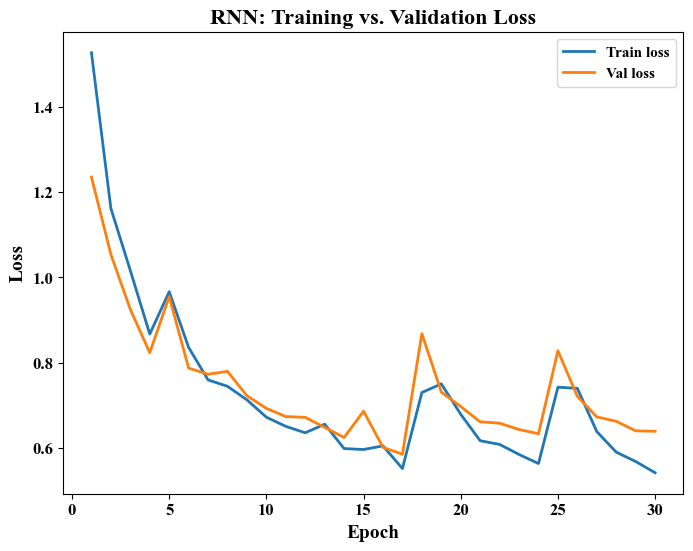

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


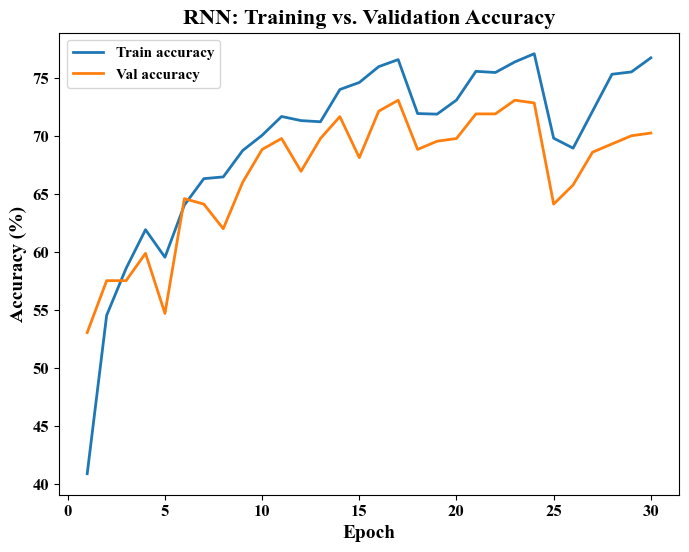

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


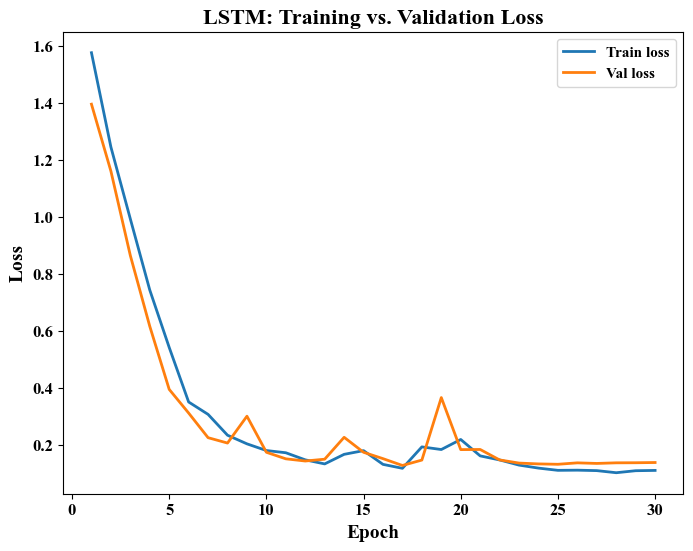

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


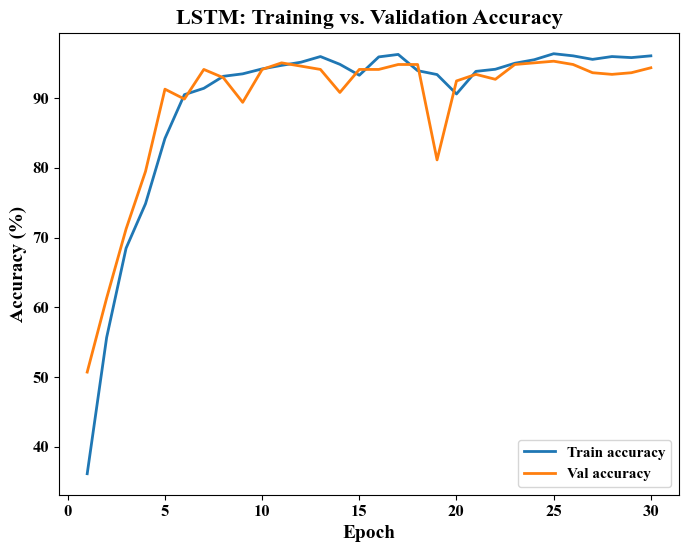

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


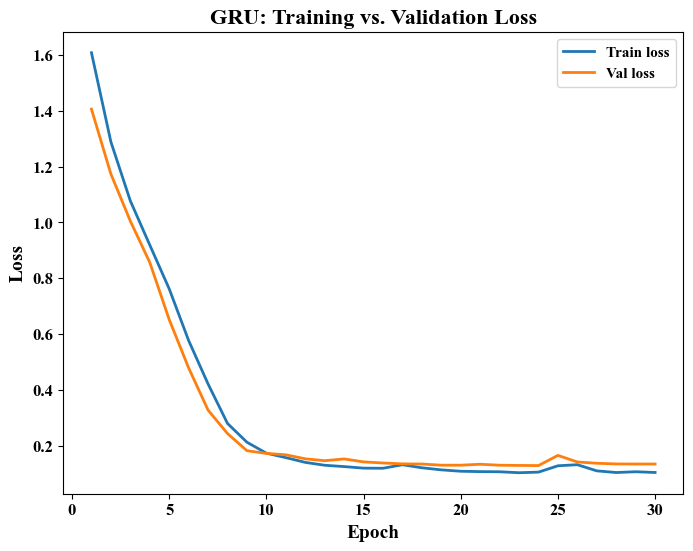

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


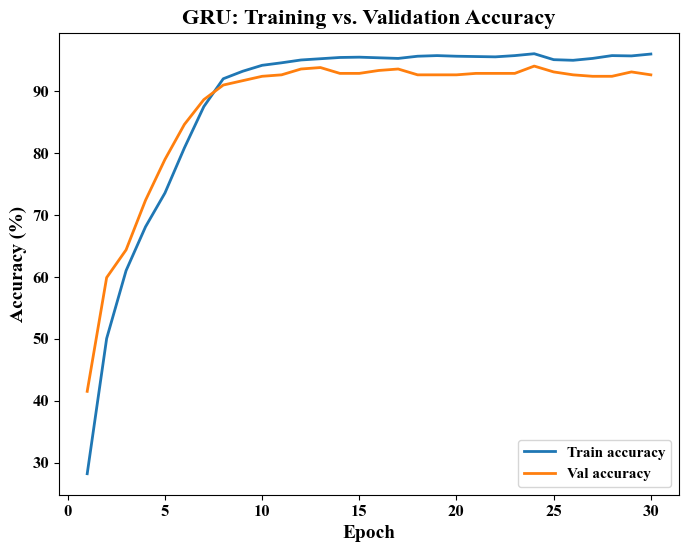

In [15]:
def plot_curves(history, model_name):
    epochs_range = range(1, len(history["loss"]) + 1)

    plt.figure()
    plt.plot(epochs_range, history["loss"], label="Train loss", linewidth=2)
    plt.plot(epochs_range, history["val_loss"], label="Val loss", linewidth=2)
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(f"{model_name}: Training vs. Validation Loss")
    plt.legend()
    save_figure(f"plot2_{model_name.lower()}_loss")
    plt.show()

    plt.figure()
    plt.plot(epochs_range, np.array(history["accuracy"]) * 100, label="Train accuracy", linewidth=2)
    plt.plot(epochs_range, np.array(history["val_accuracy"]) * 100, label="Val accuracy", linewidth=2)
    plt.xlabel("Epoch"); plt.ylabel("Accuracy (%)")
    plt.title(f"{model_name}: Training vs. Validation Accuracy")
    plt.legend()
    save_figure(f"plot3_{model_name.lower()}_accuracy")
    plt.show()

for hist, name in [(rnn_history, "RNN"), (lstm_history, "LSTM"), (gru_history, "GRU")]:
    plot_curves(hist, name)

**Inference — for each of RNN, LSTM and GRU:** does the model converge smoothly? Is there a widening
gap between training and validation curves (overfitting), or do both curves plateau high (underfitting)?
Compare convergence speed (epochs to reach a stable loss) across the three architectures.

## 8. Test-Set Evaluation — Accuracy, Precision, Recall, F1, Parameters, Training Time

In [16]:
def count_params(model):
    return int(np.sum([np.prod(w.shape) for w in model.trainable_weights]))

def evaluate_model(name, model, X_te, y_te, train_time, force=False):
    def _compute():
        y_prob = model.predict(X_te, batch_size=256, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
        return {
            "model": name,
            "accuracy":  float(accuracy_score(y_te, y_pred) * 100),
            "precision": float(precision_score(y_te, y_pred, average="macro", zero_division=0) * 100),
            "recall":    float(recall_score(y_te, y_pred, average="macro", zero_division=0) * 100),
            "f1":        float(f1_score(y_te, y_pred, average="macro", zero_division=0) * 100),
            "params":    count_params(model),
            "train_time_s": float(train_time),
            "y_pred": y_pred.tolist(),
        }
    return cached_result(f"eval_{name}", _compute, force=force)

eval_rnn  = evaluate_model("har_rnn",  rnn_model,  X_test_n, y_test, rnn_time)
eval_lstm = evaluate_model("har_lstm", lstm_model, X_test_n, y_test, lstm_time)
eval_gru  = evaluate_model("har_gru",  gru_model,  X_test_n, y_test, gru_time)

results_df = pd.DataFrame([eval_rnn, eval_lstm, eval_gru]).drop(columns=["y_pred"])
results_df = results_df.rename(columns={
    "accuracy": "Accuracy (%)", "precision": "Macro Precision (%)",
    "recall": "Macro Recall (%)", "f1": "Macro F1 (%)",
    "params": "Parameters", "train_time_s": "Training Time (s)",
})
results_df.to_csv(f"{RESULTS_DIR}/har_model_comparison.csv", index=False)
results_df

,model,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
0,har_rnn,69.290804,68.987431,68.490207,68.024700,1974,46.137621
1,har_lstm,89.107567,89.108093,89.302456,89.163170,6006,95.899653
2,har_gru,89.548694,89.547363,89.699375,89.497081,4758,121.602311


## 9. Confusion Matrix Analysis (Plot 4)

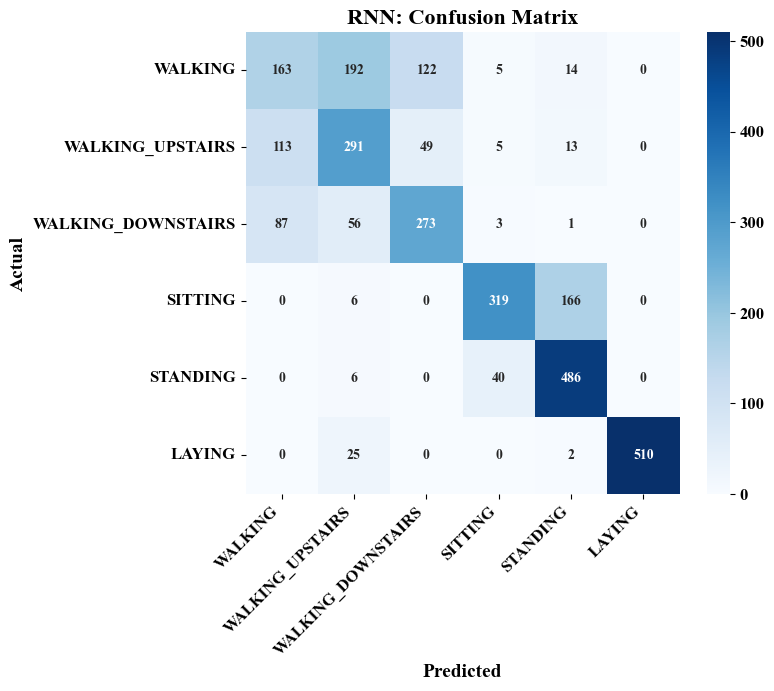

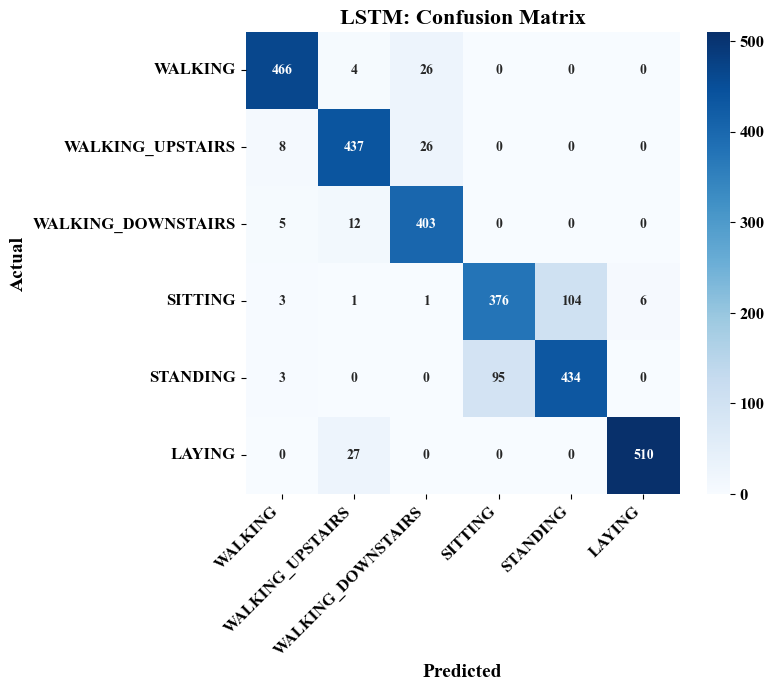

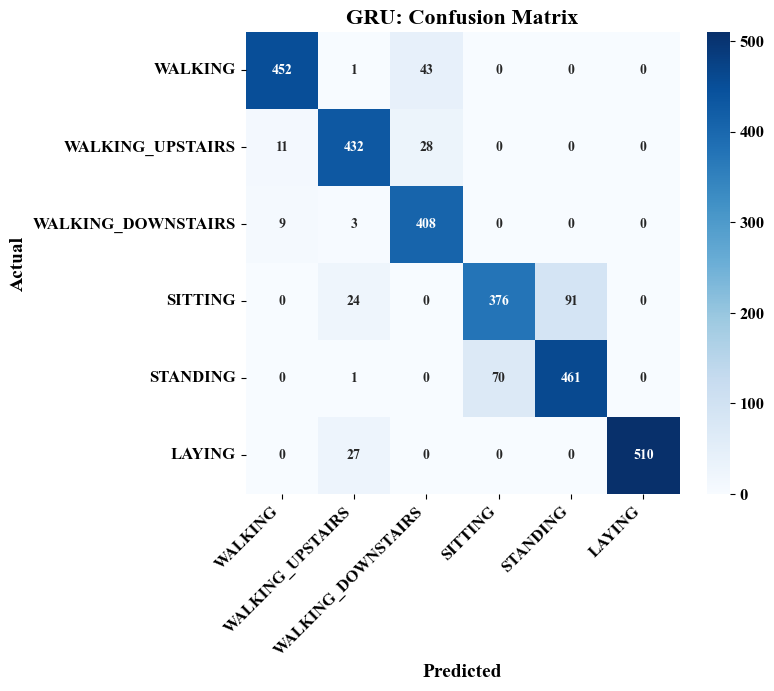

In [17]:
def plot_confusion(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    labels = [ACTIVITY_NAMES[i + 1] for i in range(N_CLASSES)]
    plt.figure(figsize=(7, 6))
    ax = sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                      xticklabels=labels, yticklabels=labels, cbar=True)
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"{model_name}: Confusion Matrix")
    plt.xticks(rotation=45, ha="right")
    save_figure(f"plot4_{model_name.lower()}_confusion")
    plt.show()
    return cm

cm_rnn  = plot_confusion(y_test, np.array(eval_rnn["y_pred"]),  "RNN")
cm_lstm = plot_confusion(y_test, np.array(eval_lstm["y_pred"]), "LSTM")
cm_gru  = plot_confusion(y_test, np.array(eval_gru["y_pred"]),  "GRU")

**Inference:** Identify (a) the activity with the highest recognition rate, (b) the activity with the
most misclassifications, (c) which activity *pairs* are most often confused (a classic HAR failure mode
is SITTING vs. STANDING, and the three WALKING variants vs. each other), and (d) whether the same
confusions recur across all three architectures or are model-specific.

## 10. RNN vs. LSTM vs. GRU — Structural and Empirical Comparison (Plot 5)

In [18]:
structural = pd.DataFrame({
    "Property": ["Hidden state", "Cell state", "Forget gate", "Input gate",
                 "Output gate", "Update gate", "Reset gate"],
    "RNN":  ["Yes", "No", "No", "No", "No", "No", "No"],
    "LSTM": ["Yes", "Yes", "Yes", "Yes", "Yes", "No", "No"],
    "GRU":  ["Yes", "No", "No", "No", "No", "Yes", "Yes"],
})
print(structural.to_string(index=False))

comparison = results_df.set_index("model")
comparison.to_csv(f"{RESULTS_DIR}/rnn_lstm_gru_comparison.csv")
comparison

    Property RNN LSTM GRU
Hidden state Yes  Yes Yes
  Cell state  No  Yes  No
 Forget gate  No  Yes  No
  Input gate  No  Yes  No
 Output gate  No  Yes  No
 Update gate  No   No Yes
  Reset gate  No   No Yes


,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
model,,,,,,
har_rnn,69.290804,68.987431,68.490207,68.024700,1974,46.137621
har_lstm,89.107567,89.108093,89.302456,89.163170,6006,95.899653
har_gru,89.548694,89.547363,89.699375,89.497081,4758,121.602311


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


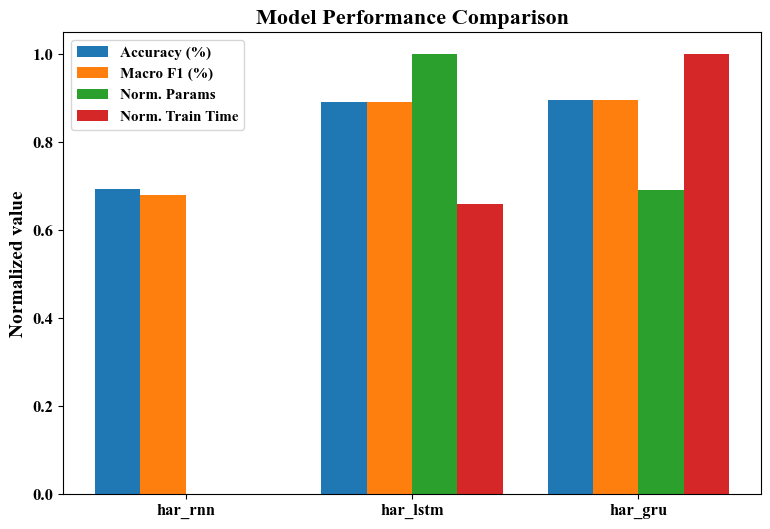

In [19]:
def normalize(series):
    return (series - series.min()) / (series.max() - series.min() + 1e-9)

fig, ax = plt.subplots(figsize=(9, 6))
metrics_to_plot = {
    "Accuracy (%)":       comparison["Accuracy (%)"] / 100,
    "Macro F1 (%)":       comparison["Macro F1 (%)"] / 100,
    "Norm. Params":       normalize(comparison["Parameters"]),
    "Norm. Train Time":   normalize(comparison["Training Time (s)"]),
}
x = np.arange(len(comparison.index))
width = 0.2
for i, (label, vals) in enumerate(metrics_to_plot.items()):
    ax.bar(x + i * width, vals.values, width, label=label)
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(comparison.index)
ax.set_ylabel("Normalized value")
ax.set_title("Model Performance Comparison")
ax.legend()
save_figure("plot5_model_comparison")
plt.show()

**Inference:** discuss the three-way trade-off between *predictive performance*, *model complexity*
(parameter count), and *training cost* (wall-clock time). Does the extra complexity of LSTM's four
gates translate into a meaningfully better F1-score than GRU's two gates on this dataset — or does GRU
get most of the benefit at lower cost?

## 11. Effect of Sequence Length (T ∈ {32, 64, 128}) — Plot 6

Each window is truncated to its first `T` time steps (a consistent, causal truncation — the model only
ever sees the *start* of the window, mirroring how a real-time system would have less context available
for shorter observation windows). All 9 (model × T) combinations are individually checkpointed.

In [20]:
SEQ_LENGTHS = [32, 64, 128]

def truncate_seq(X, T):
    return X[:, :T, :]

seqlen_results = {}

for T in SEQ_LENGTHS:
    Xtr_T = truncate_seq(X_train_n, T)
    Xva_T = truncate_seq(X_val_n, T)
    Xte_T = truncate_seq(X_test_n, T)

    for model_name, builder in [("RNN", build_rnn), ("LSTM", build_lstm), ("GRU", build_gru)]:
        run_name = f"seqlen_{model_name.lower()}_T{T}"
        print(f"\n=== {model_name}  T={T} ===")
        m, h, t_elapsed = train_with_checkpoint(
            run_name, lambda b=builder, T=T: b(input_shape=(T, 9)),
            Xtr_T, y_train, Xva_T, y_val,
        )
        ev = evaluate_model(run_name, m, Xte_T, y_test, t_elapsed)
        seqlen_results[(model_name, T)] = ev["f1"]

seqlen_table = pd.DataFrame(
    {model: [seqlen_results[(model, T)] for T in SEQ_LENGTHS] for model in ["RNN", "LSTM", "GRU"]},
    index=SEQ_LENGTHS,
)
seqlen_table.index.name = "Sequence Length"
seqlen_table.to_csv(f"{RESULTS_DIR}/sequence_length_f1.csv")
seqlen_table


=== RNN  T=32 ===
[seqlen_rnn_T32] Found completed checkpoint — loading without retraining.

=== LSTM  T=32 ===
[seqlen_lstm_T32] Found completed checkpoint — loading without retraining.

=== GRU  T=32 ===
[seqlen_gru_T32] Found completed checkpoint — loading without retraining.

=== RNN  T=64 ===
[seqlen_rnn_T64] Found completed checkpoint — loading without retraining.

=== LSTM  T=64 ===
[seqlen_lstm_T64] Found completed checkpoint — loading without retraining.

=== GRU  T=64 ===
[seqlen_gru_T64] Found completed checkpoint — loading without retraining.

=== RNN  T=128 ===
[seqlen_rnn_T128] Found completed checkpoint — loading without retraining.

=== LSTM  T=128 ===
[seqlen_lstm_T128] Found completed checkpoint — loading without retraining.

=== GRU  T=128 ===
[seqlen_gru_T128] Found completed checkpoint — loading without retraining.


,RNN,LSTM,GRU
Sequence Length,,,
32,70.831338,86.434479,86.795154
64,69.633646,91.556092,89.786000
128,67.679019,89.514732,89.315357


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


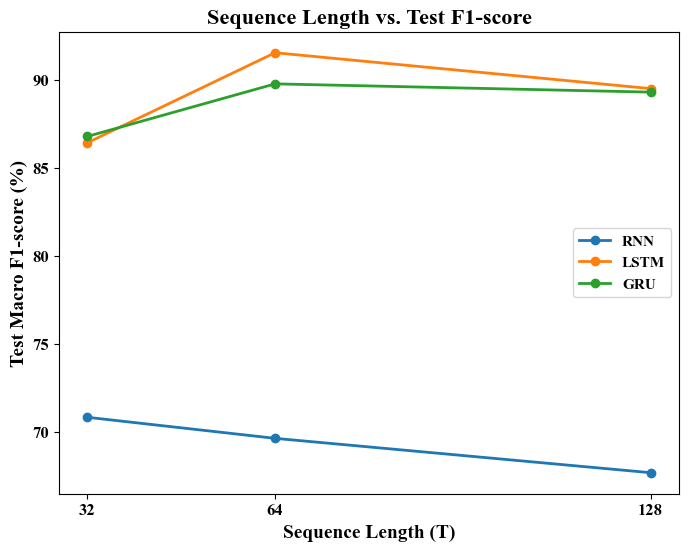

In [21]:
plt.figure()
for model in ["RNN", "LSTM", "GRU"]:
    plt.plot(SEQ_LENGTHS, seqlen_table[model], marker="o", linewidth=2, label=model)
plt.xlabel("Sequence Length (T)")
plt.ylabel("Test Macro F1-score (%)")
plt.title("Sequence Length vs. Test F1-score")
plt.xticks(SEQ_LENGTHS)
plt.legend()
save_figure("plot6_seqlen_vs_f1")
plt.show()

**Inference:** how does reducing the amount of temporal context (shorter `T`) affect classification
performance for each architecture? Which model degrades most gracefully at short sequence lengths, and
why might that relate to how each architecture propagates information through time (vanishing gradients
in vanilla RNN vs. the gating mechanisms in LSTM/GRU)?

## 12. Video Understanding Using CNN + RNN

This section builds the CNN-feature-extraction + LSTM/GRU pipeline on a small subset of **UCF101**.

**Important practical note on the dataset.** UCF101 is only distributed as a single ~6.9&nbsp;GB `.rar`
archive from `crcv.ucf.edu` — there is no official per-class download, and the archive requires `unrar`
to extract. This cell therefore tries, in order:

1. **Local folder** — if you have already placed videos at `data/UCF101_subset/<ClassName>/*.avi`
   (e.g. by manually downloading the archive once and copying out 3-5 class folders), it uses those.
2. **KaggleHub** — if the `kagglehub` package and Kaggle credentials are available, it pulls a
   community mirror of UCF101 and copies out the selected classes.
3. **Synthetic fallback** — if neither is available, it generates small synthetic "videos"
   (structured moving-shape sequences, one visual pattern per class) purely so the **pipeline itself**
   (frame sampling → CNN features → LSTM/GRU → evaluation) can be run and understood end-to-end without
   a multi-gigabyte download blocking you. This is clearly flagged in the output — replace it with real
   UCF101 clips for your actual submission numbers.

All three paths converge to the same `data/UCF101_subset/<ClassName>/*` layout, so everything downstream
is identical regardless of which path was used.

In [22]:
VIDEO_CLASSES = ["Basketball", "Biking", "WalkingWithDog", "JumpingJack", "TennisSwing"]  # real UCF101 class names
VIDEOS_PER_CLASS = 8          # small, computationally manageable subset
FRAMES_PER_VIDEO = 10
FRAME_SIZE = (224, 224)

VIDEO_ROOT = f"{DATA_DIR}/UCF101_subset"
os.makedirs(VIDEO_ROOT, exist_ok=True)

REMOTE_ZIP_URL = "https://storage.googleapis.com/thumos14_files/UCF101_videos.zip"
REMOTE_ZIP_MANIFEST_CACHE = f"{CKPT_DIR}/ucf101_remote_manifest.json"

def existing_class_video_counts():
    counts = {}
    for c in VIDEO_CLASSES:
        cdir = os.path.join(VIDEO_ROOT, c)
        n = len(glob.glob(os.path.join(cdir, "*.avi"))) + len(glob.glob(os.path.join(cdir, "*.mp4"))) \
            + len(glob.glob(os.path.join(cdir, "*.npy")))  # .npy = synthetic fallback videos
        counts[c] = n
    return counts

USING_SYNTHETIC_VIDEO = False

def _get_class_from_ucf_filename(fname):
    # Filenames look like 'UCF101/v_Basketball_g01_c01.avi' -> 3rd-from-last underscore-split token.
    return fname.split("_")[-3]

def _try_remotezip_download():
    """Downloads only the needed files from the Google-hosted UCF101 zip mirror using range
    requests, instead of the full ~6.9 GB archive. Returns True on success."""
    try:
        import remotezip as rz
    except ImportError:
        print("`remotezip` not installed — attempting `pip install remotezip` ...")
        import subprocess, sys
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "remotezip"])
            import remotezip as rz
        except Exception as e:
            print(f"Could not install remotezip ({e}); skipping this path.")
            return False

    try:
        # Cache the (large) file listing so re-runs don't re-fetch the zip's central directory.
        if os.path.exists(REMOTE_ZIP_MANIFEST_CACHE):
            all_files = load_json(REMOTE_ZIP_MANIFEST_CACHE)
        else:
            print("Listing files in remote UCF101 zip mirror (no video data downloaded yet)...")
            with rz.RemoteZip(REMOTE_ZIP_URL) as zf:
                all_files = [i.filename for i in zf.infolist() if i.filename.endswith(".avi")]
            save_json(all_files, REMOTE_ZIP_MANIFEST_CACHE)
        print(f"Remote archive contains {len(all_files)} .avi files total.")

        files_by_class = {}
        for fn in all_files:
            cls = _get_class_from_ucf_filename(fn)
            files_by_class.setdefault(cls, []).append(fn)

        missing = [c for c in VIDEO_CLASSES if c not in files_by_class or len(files_by_class[c]) == 0]
        if missing:
            print(f"These requested classes were not found in the remote archive: {missing}")
            return False

        rng = np.random.RandomState(SEED)
        with rz.RemoteZip(REMOTE_ZIP_URL) as zf:
            for c in VIDEO_CLASSES:
                dst_dir = os.path.join(VIDEO_ROOT, c)
                os.makedirs(dst_dir, exist_ok=True)
                have = len(glob.glob(os.path.join(dst_dir, "*.avi")))
                if have >= VIDEOS_PER_CLASS:
                    continue
                candidates = sorted(files_by_class[c])
                rng.shuffle(candidates)
                chosen = candidates[:VIDEOS_PER_CLASS]
                print(f"  downloading {len(chosen)} videos for class '{c}'...")
                for fn in chosen:
                    zf.extract(fn, dst_dir)
                    extracted_path = os.path.join(dst_dir, fn)   # keeps the 'UCF101/' prefix subfolder
                    final_path = os.path.join(dst_dir, os.path.basename(fn))
                    if extracted_path != final_path:
                        shutil.move(extracted_path, final_path)
                # clean up any now-empty nested folder remotezip created (e.g. dst_dir/UCF101/)
                nested = os.path.join(dst_dir, "UCF101")
                if os.path.isdir(nested) and not os.listdir(nested):
                    os.rmdir(nested)
        return True
    except Exception as e:
        print(f"remotezip partial download failed ({e}); falling back to the next option.")
        return False

def acquire_video_subset(force=False):
    global USING_SYNTHETIC_VIDEO
    counts = existing_class_video_counts()
    if all(n >= VIDEOS_PER_CLASS for n in counts.values()) and not force:
        print("Video subset already present on disk:", counts)
        USING_SYNTHETIC_VIDEO = any(
            glob.glob(os.path.join(VIDEO_ROOT, c, "*.npy")) for c in VIDEO_CLASSES
        )
        return

    # --- Path 2: remotezip partial download (fast, recommended) ----------
    print("Attempting fast partial download via remotezip...")
    if _try_remotezip_download():
        counts = existing_class_video_counts()
        if all(n >= 1 for n in counts.values()):
            print("remotezip subset acquired:", counts)
            return
        print("remotezip path did not yield all requested classes; trying KaggleHub next.")

    # --- Path 3: KaggleHub mirror (slow — full-archive download) ----------
    try:
        import kagglehub
        print("Attempting KaggleHub download of a UCF101 mirror (this pulls the full ~6.5 GB archive)...")
        ds_path = kagglehub.dataset_download("matthewjansen/ucf101-action-recognition")
        for c in VIDEO_CLASSES:
            src_candidates = glob.glob(os.path.join(ds_path, "**", c, "*"), recursive=True)
            dst_dir = os.path.join(VIDEO_ROOT, c)
            os.makedirs(dst_dir, exist_ok=True)
            for src in src_candidates[:VIDEOS_PER_CLASS]:
                shutil.copy(src, dst_dir)
        counts = existing_class_video_counts()
        if all(n >= 1 for n in counts.values()):
            print("KaggleHub subset acquired:", counts)
            return
        print("KaggleHub path did not yield all requested classes; falling back to synthetic data.")
    except Exception as e:
        print(f"KaggleHub path unavailable ({e}); falling back to synthetic data.")

    # --- Path 4: synthetic fallback (guarantees the notebook always runs) -
    print("\n*** Using SYNTHETIC placeholder videos — replace with real UCF101 clips for a real submission. ***\n")
    USING_SYNTHETIC_VIDEO = True
    rng = np.random.RandomState(SEED)
    for ci, c in enumerate(VIDEO_CLASSES):
        dst_dir = os.path.join(VIDEO_ROOT, c)
        os.makedirs(dst_dir, exist_ok=True)
        for v in range(VIDEOS_PER_CLASS):
            frames = np.zeros((FRAMES_PER_VIDEO, *FRAME_SIZE, 3), dtype=np.uint8)
            speed = 8 + 4 * ci
            radius = 15 + 5 * (ci % 3)
            color = np.array([(ci * 53) % 255, (ci * 97) % 255, (ci * 151) % 255])
            y0 = rng.randint(40, FRAME_SIZE[0] - 40)
            x0 = rng.randint(40, FRAME_SIZE[1] - 40)
            for t in range(FRAMES_PER_VIDEO):
                yy, xx = np.ogrid[:FRAME_SIZE[0], :FRAME_SIZE[1]]
                cy = (y0 + speed * t) % FRAME_SIZE[0]
                cx = (x0 + speed * t) % FRAME_SIZE[1]
                mask = (yy - cy) ** 2 + (xx - cx) ** 2 <= radius ** 2
                frames[t][mask] = color
            np.save(os.path.join(dst_dir, f"synthetic_{v:03d}.npy"), frames)
    print("Synthetic subset ready:", existing_class_video_counts())

acquire_video_subset()

Video subset already present on disk: {'Basketball': 16, 'Biking': 16, 'WalkingWithDog': 16, 'JumpingJack': 8, 'TennisSwing': 16}


## 13. Frame Extraction — Uniform Sampling of 10 Frames per Video

In [23]:
# --- One-time cleanup: remove leftover synthetic placeholder files now that
# real UCF101 clips are on disk, and clear any caches/checkpoints that were
# computed from bad (black-frame) reads earlier in this session. ---
import glob, os

removed_synthetic = 0
for f in glob.glob(os.path.join(VIDEO_ROOT, "*", "synthetic_*.npy")):
    os.remove(f)
    removed_synthetic += 1
print(f"Removed {removed_synthetic} leftover synthetic .npy files.")

removed_features = 0
if os.path.isdir(FEATURE_DIR) if 'FEATURE_DIR' in dir() else False:
    for f in glob.glob(f"{FEATURE_DIR}/*.npy"):
        os.remove(f)
        removed_features += 1
print(f"Removed {removed_features} cached CNN feature files (will be recomputed from real frames).")

removed_ckpts = 0
for f in glob.glob("checkpoints/video_cnn_lstm_*") + glob.glob("checkpoints/video_cnn_gru_*"):
    os.remove(f)
    removed_ckpts += 1
print(f"Removed {removed_ckpts} stale video-model checkpoint files (will retrain fresh).")

Removed 40 leftover synthetic .npy files.
Removed 0 cached CNN feature files (will be recomputed from real frames).
Removed 10 stale video-model checkpoint files (will retrain fresh).


In [24]:
def read_video_frames(path, n_frames=FRAMES_PER_VIDEO, size=FRAME_SIZE):
    """Uniformly samples n_frames frames from a video file (or a .npy synthetic stand-in),
    resized to `size` x 3. Tries imageio (ffmpeg backend) first — more reliable than OpenCV's
    bundled ffmpeg for older codecs like the XVID/MPEG-4 used in UCF101 .avi files — and falls
    back to OpenCV if imageio is unavailable or fails."""
    if path.endswith(".npy"):
        frames = np.load(path)
        idxs = np.linspace(0, len(frames) - 1, n_frames).astype(int)
        out = frames[idxs]
        if out.shape[1:3] != size:
            import cv2
            out = np.stack([cv2.resize(f, size) for f in out])
        return out.astype(np.float32)

    # --- Primary path: imageio + ffmpeg plugin -----------------------------
    try:
        import imageio.v3 as iio
        all_frames = iio.imread(path, plugin="FFMPEG")  # (T, H, W, 3), RGB, uint8
        if len(all_frames) == 0:
            raise ValueError("imageio decoded 0 frames")
        idxs = np.linspace(0, len(all_frames) - 1, n_frames).astype(int)
        frames = all_frames[idxs]
        import cv2
        frames = np.stack([cv2.resize(f, size) for f in frames])
        return frames.astype(np.float32)
    except Exception as e:
        print(f"  [imageio decode failed for {os.path.basename(path)}: {e} — falling back to OpenCV]")

    # --- Fallback path: OpenCV ----------------------------------------------
    import cv2
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        raise ValueError(f"Could not read frame count for {path}")

    idxs = np.linspace(0, max(total - 1, 0), n_frames).astype(int)
    frames = []
    for target_idx in idxs:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(target_idx))
        ret, frame = cap.read()
        if not ret:
            frame = frames[-1] if frames else np.zeros((*size, 3), dtype=np.uint8)
        else:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, size)
        frames.append(frame)
    cap.release()

    while len(frames) < n_frames:  # pad if the video was shorter than expected
        frames.append(frames[-1])
    return np.stack(frames[:n_frames]).astype(np.float32)

# Collect the (path, class) manifest. Sorted alphabetically per class, then capped to
# VIDEOS_PER_CLASS — now that synthetic files are removed (see cleanup cell above), this
# only ever picks real .avi files.
video_manifest = []
for c in VIDEO_CLASSES:
    files = sorted(glob.glob(os.path.join(VIDEO_ROOT, c, "*")))
    for fp in files[:VIDEOS_PER_CLASS]:
        video_manifest.append((fp, c))
print(f"Total videos in manifest: {len(video_manifest)}")
pd.Series([c for _, c in video_manifest]).value_counts()

Total videos in manifest: 40


Basketball        8
Biking            8
WalkingWithDog    8
JumpingJack       8
TennisSwing       8
Name: count, dtype: int64

## 14. CNN Feature Extraction (MobileNetV2, Frozen)

Each video's 10 frames are pushed through a frozen, pretrained MobileNetV2 (ImageNet weights) with
global average pooling to obtain one feature vector per frame. **Extraction is cached per video** as a
`.npy` file — re-running this cell only extracts features for videos that don't already have one.

In [25]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

FEATURE_DIR = f"{CKPT_DIR}/video_features"
os.makedirs(FEATURE_DIR, exist_ok=True)

_feature_extractor = None
def get_feature_extractor():
    global _feature_extractor
    if _feature_extractor is None:
        base = MobileNetV2(include_top=False, weights="imagenet", pooling="avg",
                            input_shape=(*FRAME_SIZE, 3))
        base.trainable = False  # freeze — we only use it for feature extraction
        _feature_extractor = base
    return _feature_extractor

def feature_cache_path(video_path):
    stem = os.path.splitext(os.path.basename(video_path))[0]
    cls = os.path.basename(os.path.dirname(video_path))
    return os.path.join(FEATURE_DIR, f"{cls}__{stem}.npy")

def extract_features_for_manifest(manifest, force=False, batch_size=64):
    extractor = None
    D = None
    all_features = []
    all_labels = []

    for i, (path, cls) in enumerate(manifest):
        cache_path = feature_cache_path(path)
        if os.path.exists(cache_path) and not force:
            feats = np.load(cache_path)
        else:
            if extractor is None:
                extractor = get_feature_extractor()
            frames = read_video_frames(path)                       # (10, 224, 224, 3)
            frames_pp = mobilenet_preprocess(frames.copy())
            feats = extractor.predict(frames_pp, batch_size=batch_size, verbose=0)  # (10, D)
            np.save(cache_path, feats)
        D = feats.shape[-1]
        all_features.append(feats)
        all_labels.append(cls)
        if (i + 1) % 5 == 0 or (i + 1) == len(manifest):
            print(f"  features ready: {i+1}/{len(manifest)}")

    X_video = np.stack(all_features).astype(np.float32)  # (B, 10, D)
    return X_video, all_labels, D

X_video, video_labels_raw, FEATURE_DIM = extract_features_for_manifest(video_manifest)
print("CNN feature tensor supplied to the recurrent network:", X_video.shape)
print("Per-frame CNN feature dimension D =", FEATURE_DIM)

  features ready: 5/40
  features ready: 10/40
  features ready: 15/40
  features ready: 20/40
  features ready: 25/40
  features ready: 30/40
  features ready: 35/40
  features ready: 40/40
CNN feature tensor supplied to the recurrent network: (40, 10, 1280)
Per-frame CNN feature dimension D = 1280


In [26]:
video_class_to_idx = {c: i for i, c in enumerate(VIDEO_CLASSES)}
y_video = np.array([video_class_to_idx[c] for c in video_labels_raw])

Xv_trainval, Xv_test, yv_trainval, yv_test = train_test_split(
    X_video, y_video, test_size=0.2, stratify=y_video, random_state=SEED
)
Xv_train, Xv_val, yv_train, yv_val = train_test_split(
    Xv_trainval, yv_trainval, test_size=0.2, stratify=yv_trainval, random_state=SEED
)
print("Video train/val/test:", Xv_train.shape, Xv_val.shape, Xv_test.shape)

Video train/val/test: (25, 10, 1280) (7, 10, 1280) (8, 10, 1280)


## 15. CNN-LSTM / CNN-GRU Model — Training

In [27]:
def build_video_classifier(recurrent_layer_cls, feature_dim, num_classes=len(VIDEO_CLASSES),
                            units=RECURRENT_UNITS, name="video_model"):
    inputs = layers.Input(shape=(FRAMES_PER_VIDEO, feature_dim), name="frame_features")
    x = recurrent_layer_cls(units, name="recurrent")(inputs)
    x = layers.Dropout(DROPOUT_RATE)(x)
    outputs = layers.Dense(num_classes, activation="softmax", dtype="float32")(x)
    model = keras.Model(inputs, outputs, name=name)
    model.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def build_cnn_lstm(feature_dim=FEATURE_DIM):
    return build_video_classifier(layers.LSTM, feature_dim, name="CNN_LSTM")

def build_cnn_gru(feature_dim=FEATURE_DIM):
    return build_video_classifier(layers.GRU, feature_dim, name="CNN_GRU")

# Small dataset -> fewer epochs needed; still fully checkpointed/resumable.
VIDEO_EPOCHS = 20

cnn_lstm_model, cnn_lstm_history, cnn_lstm_time = train_with_checkpoint(
    "video_cnn_lstm", build_cnn_lstm, Xv_train, yv_train, Xv_val, yv_val, epochs=VIDEO_EPOCHS
)

[video_cnn_lstm] No checkpoint found — starting fresh.
Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.0400 - loss: 1.9381 - val_accuracy: 0.4286 - val_loss: 1.4273
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.5200 - loss: 1.4538 - val_accuracy: 0.8571 - val_loss: 1.2108
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.7600 - loss: 1.0693 - val_accuracy: 1.0000 - val_loss: 1.0117
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.9200 - loss: 0.8207 - val_accuracy: 1.0000 - val_loss: 0.8860
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 1.0000 - loss: 0.6497 - val_accuracy: 1.0000 - val_loss: 0.8219
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.9600 - loss: 0.6230 - val_accuracy: 1.0000 - val_loss: 0.7654
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 1.0000 - loss: 0.4823 - val_accuracy: 1.0000 - val_loss: 0.6961
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 1.00

In [28]:
cnn_gru_model, cnn_gru_history, cnn_gru_time = train_with_checkpoint(
    "video_cnn_gru", build_cnn_gru, Xv_train, yv_train, Xv_val, yv_val, epochs=VIDEO_EPOCHS
)

[video_cnn_gru] No checkpoint found — starting fresh.
Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.0400 - loss: 2.0203 - val_accuracy: 0.1429 - val_loss: 1.5428
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.3200 - loss: 1.5392 - val_accuracy: 0.4286 - val_loss: 1.3622
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.5200 - loss: 1.0806 - val_accuracy: 0.5714 - val_loss: 1.2421
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.7200 - loss: 0.9301 - val_accuracy: 0.5714 - val_loss: 1.1285
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.8800 - loss: 0.7076 - val_accuracy: 0.5714 - val_loss: 1.0250
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.8400 - loss: 0.6111 - val_accuracy: 0.5714 - val_loss: 0.9245
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.9200 - loss: 0.4694 - val_accuracy: 0.7143 - val_loss: 0.8225
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 1.000

## 16. Video Sample Frames, Training Curves, and Confusion Matrix (Plots 7-9)

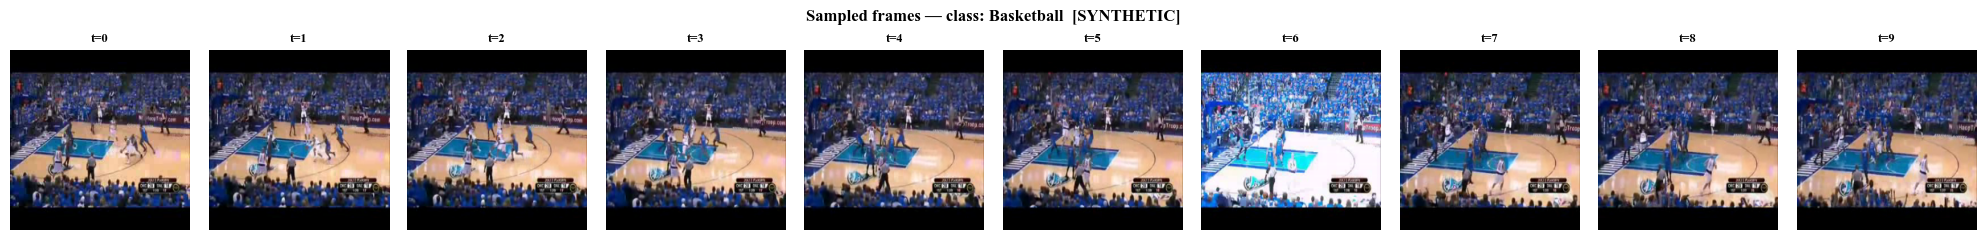

In [29]:
# Plot 7: sample frames from one representative video.
sample_path, sample_cls = video_manifest[0]
sample_frames = read_video_frames(sample_path)
fig, axes = plt.subplots(1, FRAMES_PER_VIDEO, figsize=(2 * FRAMES_PER_VIDEO, 2.4))
for i, ax in enumerate(axes):
    ax.imshow(sample_frames[i].astype(np.uint8))
    ax.set_title(f"t={i}", fontsize=9, fontweight="bold")
    ax.axis("off")
fig.suptitle(f"Sampled frames — class: {sample_cls}"
             + ("  [SYNTHETIC]" if USING_SYNTHETIC_VIDEO else ""), fontweight="bold")
plt.tight_layout()
plt.savefig(f"{IMAGES_DIR}/plot7_video_frames.png", format="png", dpi=200, bbox_inches="tight")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


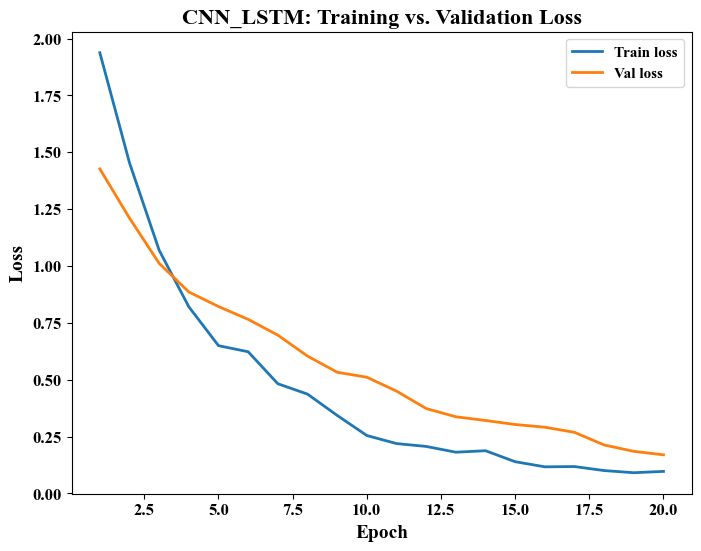

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


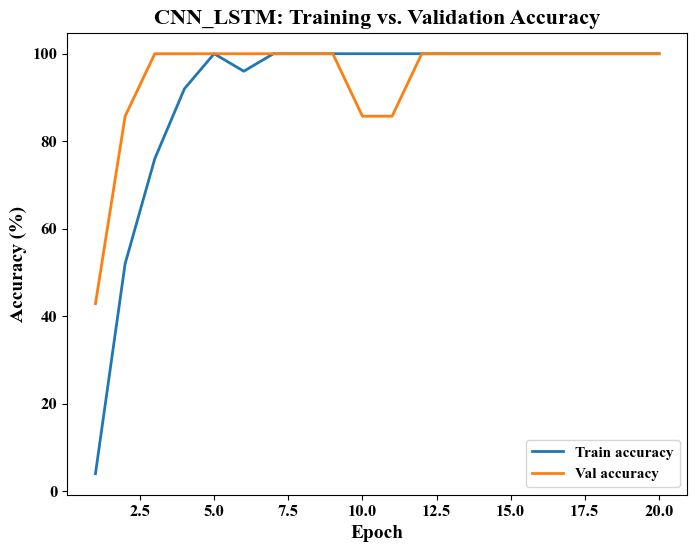

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


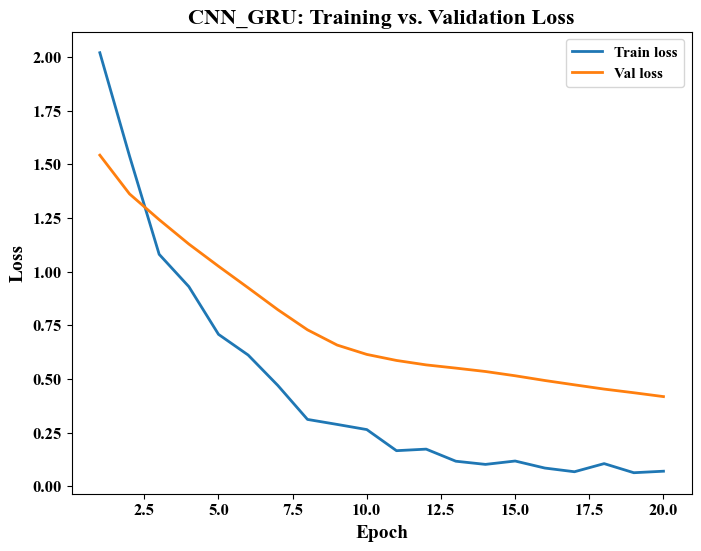

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


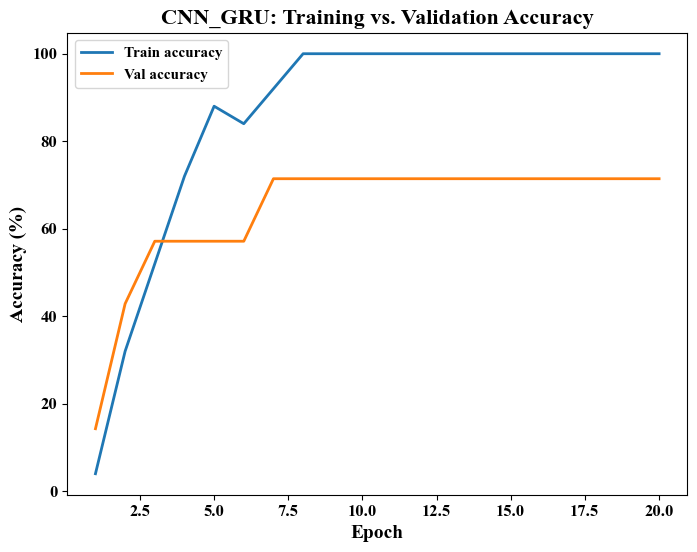

In [30]:
plot_curves(cnn_lstm_history, "CNN_LSTM")
plot_curves(cnn_gru_history, "CNN_GRU")

In [31]:
eval_cnn_lstm = evaluate_model("video_cnn_lstm", cnn_lstm_model, Xv_test, yv_test, cnn_lstm_time)
eval_cnn_gru  = evaluate_model("video_cnn_gru",  cnn_gru_model,  Xv_test, yv_test, cnn_gru_time)

video_results_df = pd.DataFrame([eval_cnn_lstm, eval_cnn_gru]).drop(columns=["y_pred"])
video_results_df = video_results_df.rename(columns={
    "accuracy": "Accuracy (%)", "precision": "Macro Precision (%)",
    "recall": "Macro Recall (%)", "f1": "Macro F1 (%)",
    "params": "Parameters", "train_time_s": "Training Time (s)",
})
video_results_df.to_csv(f"{RESULTS_DIR}/video_model_comparison.csv", index=False)
video_results_df

,model,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
0,video_cnn_lstm,100.0,100.0,100.0,100.0,168229,7.910281
1,video_cnn_gru,100.0,100.0,100.0,100.0,126309,8.081426


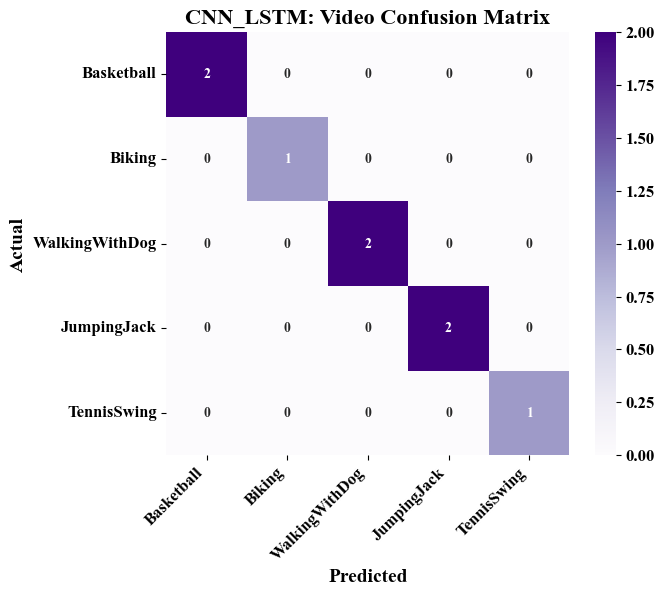

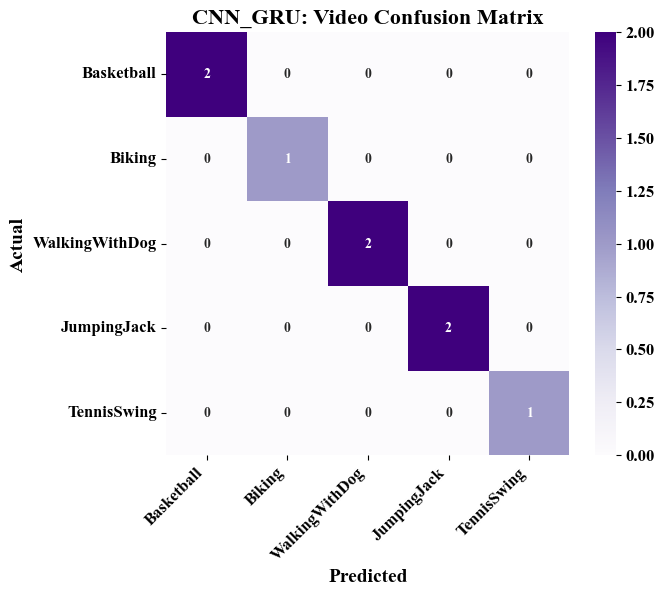


NOTE: these video results were produced on SYNTHETIC placeholder clips (see Section 12). Re-run Section 12 onward with real UCF101 videos in data/UCF101_subset/<ClassName>/ before treating these numbers as your submission results.


In [32]:
def plot_video_confusion(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(VIDEO_CLASSES))))
    plt.figure(figsize=(6.5, 5.5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
                xticklabels=VIDEO_CLASSES, yticklabels=VIDEO_CLASSES)
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"{model_name}: Video Confusion Matrix")
    plt.xticks(rotation=45, ha="right")
    save_figure(f"plot9_{model_name.lower()}_video_confusion")
    plt.show()

plot_video_confusion(yv_test, np.array(eval_cnn_lstm["y_pred"]), "CNN_LSTM")
plot_video_confusion(yv_test, np.array(eval_cnn_gru["y_pred"]),  "CNN_GRU")

if USING_SYNTHETIC_VIDEO:
    print("\nNOTE: these video results were produced on SYNTHETIC placeholder clips "
          "(see Section 12). Re-run Section 12 onward with real UCF101 videos in "
          "data/UCF101_subset/<ClassName>/ before treating these numbers as your submission results.")

**Inference:** what spatial information does the frozen CNN capture per frame, and what *temporal*
information does the LSTM/GRU add on top of that? Discuss class-level recognition and any
temporally-confused action pairs (e.g. visually similar motions).

## 17. Sequence-to-Sequence Learning: Synthetic Reversal Task

A minimal encoder-decoder (`[3, 8, 1, 5] -> [5, 1, 8, 3]`) trained with **teacher forcing**, using
separate inference-time encoder/decoder models for greedy autoregressive decoding at test time.

In [33]:
SEQ2SEQ_MIN_VAL, SEQ2SEQ_MAX_VAL = 1, 20      # integer vocabulary range for the sequence content
SEQ2SEQ_LEN = 6
PAD_TOKEN, SOS_TOKEN, EOS_TOKEN = 0, SEQ2SEQ_MAX_VAL + 1, SEQ2SEQ_MAX_VAL + 2
SEQ2SEQ_VOCAB_SIZE = SEQ2SEQ_MAX_VAL + 3   # + PAD, SOS, EOS
N_SEQ2SEQ_SAMPLES = 8000

def generate_reversal_dataset(n_samples=N_SEQ2SEQ_SAMPLES, seq_len=SEQ2SEQ_LEN, seed=SEED):
    rng = np.random.RandomState(seed)
    src = rng.randint(SEQ2SEQ_MIN_VAL, SEQ2SEQ_MAX_VAL + 1, size=(n_samples, seq_len))
    tgt = src[:, ::-1].copy()

    # Decoder input:  <SOS> + target        (length L+1, teacher forcing)
    # Decoder target: target + <EOS>        (length L+1)
    # Both must have the SAME length L+1: input token at position t is used to
    # predict target token at position t (input[0]=SOS predicts target[0]=y1,
    # input[1]=y1 predicts target[1]=y2, ..., input[L]=yL predicts target[L]=EOS).
    dec_input = np.concatenate([np.full((n_samples, 1), SOS_TOKEN), tgt], axis=1)
    dec_target = np.concatenate([tgt, np.full((n_samples, 1), EOS_TOKEN)], axis=1)
    return src.astype(np.int32), dec_input.astype(np.int32), dec_target.astype(np.int32)

enc_in_all, dec_in_all, dec_tgt_all = generate_reversal_dataset()

enc_in_tr, enc_in_te, dec_in_tr, dec_in_te, dec_tgt_tr, dec_tgt_te = train_test_split(
    enc_in_all, dec_in_all, dec_tgt_all, test_size=0.2, random_state=SEED
)
enc_in_tr, enc_in_va, dec_in_tr, dec_in_va, dec_tgt_tr, dec_tgt_va = train_test_split(
    enc_in_tr, dec_in_tr, dec_tgt_tr, test_size=0.125, random_state=SEED  # 0.125 of 0.8 = 0.1 overall
)
print("seq2seq train/val/test:", enc_in_tr.shape, enc_in_va.shape, enc_in_te.shape)
print("Example — input:", enc_in_all[0], " reversed target:", enc_in_all[0][::-1])

seq2seq train/val/test: (5600, 6) (800, 6) (1600, 6)
Example — input: [ 7 20 15 11  8  7]  reversed target: [ 7  8 11 15 20  7]


## 18. Encoder-Decoder Architecture

The training-time graph uses **teacher forcing** (the true previous target token is fed to the decoder
at every step, rather than the model's own prediction) — this stabilizes and speeds up training
substantially versus always feeding back predictions. Separate lightweight inference models reuse the
trained layers for greedy autoregressive decoding at test time, where teacher forcing is not available.

In [34]:
SEQ2SEQ_EMBED_DIM = 32
SEQ2SEQ_UNITS = 64

def build_seq2seq_models():
    # ---- Training graph (teacher forcing) ----
    encoder_inputs = layers.Input(shape=(None,), name="encoder_input")
    enc_emb_layer = layers.Embedding(SEQ2SEQ_VOCAB_SIZE, SEQ2SEQ_EMBED_DIM, mask_zero=True, name="enc_embed")
    enc_emb = enc_emb_layer(encoder_inputs)
    encoder_lstm = layers.LSTM(SEQ2SEQ_UNITS, return_state=True, name="encoder_lstm")
    _, state_h, state_c = encoder_lstm(enc_emb)
    encoder_states = [state_h, state_c]

    decoder_inputs = layers.Input(shape=(None,), name="decoder_input")
    dec_emb_layer = layers.Embedding(SEQ2SEQ_VOCAB_SIZE, SEQ2SEQ_EMBED_DIM, mask_zero=True, name="dec_embed")
    dec_emb = dec_emb_layer(decoder_inputs)
    decoder_lstm = layers.LSTM(SEQ2SEQ_UNITS, return_sequences=True, return_state=True, name="decoder_lstm")
    decoder_outputs, _, _ = decoder_lstm(dec_emb, initial_state=encoder_states)
    decoder_dense = layers.Dense(SEQ2SEQ_VOCAB_SIZE, activation="softmax", dtype="float32", name="decoder_dense")
    decoder_outputs = decoder_dense(decoder_outputs)

    train_model = keras.Model([encoder_inputs, decoder_inputs], decoder_outputs, name="seq2seq_train")
    train_model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                         loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    # ---- Inference encoder: input sequence -> final states ----
    encoder_infer_model = keras.Model(encoder_inputs, encoder_states, name="seq2seq_encoder_infer")

    # ---- Inference decoder: one step at a time, states fed back in ----
    dec_state_input_h = layers.Input(shape=(SEQ2SEQ_UNITS,))
    dec_state_input_c = layers.Input(shape=(SEQ2SEQ_UNITS,))
    dec_single_input = layers.Input(shape=(1,))
    dec_single_emb = dec_emb_layer(dec_single_input)
    dec_single_out, dh, dc = decoder_lstm(dec_single_emb, initial_state=[dec_state_input_h, dec_state_input_c])
    dec_single_pred = decoder_dense(dec_single_out)
    decoder_infer_model = keras.Model(
        [dec_single_input, dec_state_input_h, dec_state_input_c],
        [dec_single_pred, dh, dc],
        name="seq2seq_decoder_infer",
    )

    return train_model, encoder_infer_model, decoder_infer_model

seq2seq_train_model, seq2seq_encoder_infer, seq2seq_decoder_infer = build_seq2seq_models()
seq2seq_train_model.summary()

Model: "seq2seq_train"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)    │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ decoder_input (InputLayer)    │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ enc_embed (Embedding)         │ (None, None, 32)          │             736 │ encoder_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal (NotEqual)          │ (None, None)              │               0 │ encoder_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dec_embed (Embedding)         │ (None, 1, 32)             │             736 │ decoder_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ encoder_lstm (LSTM)           │ [(None, 64), (None, 64),  │          24,832 │ enc_embed[0][0],           │
│                               │ (None, 64)]               │                 │ not_equal[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ decoder_lstm (LSTM)           │ [(None, 1, 64), (None,    │          24,832 │ dec_embed[0][0],           │
│                               │ 64), (None, 64)]          │                 │ encoder_lstm[0][1],        │
│                               │                           │                 │ encoder_lstm[0][2]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ decoder_dense (Dense)         │ (None, 1, 23)             │           1,495 │ decoder_lstm[0][0]         │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 52,631 (205.59 KB)

 Trainable params: 52,631 (205.59 KB)

 Non-trainable params: 0 (0.00 B)

## 19. Training the Seq2Seq Model (Checkpointed)

[seq2seq_reversal] Starting fresh...
Epoch 1/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.1630 - loss: 2.9729 - val_accuracy: 0.2680 - val_loss: 2.4369
Epoch 2/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.2982 - loss: 2.3138 - val_accuracy: 0.3582 - val_loss: 2.0409
Epoch 3/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3805 - loss: 1.9481 - val_accuracy: 0.4738 - val_loss: 1.6407
Epoch 4/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5279 - loss: 1.4929 - val_accuracy: 0.6916 - val_loss: 1.1070
Epoch 5/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7368 - loss: 0.9787 - val_accuracy: 0.8346 - val_loss: 0.7290
Epoch 6/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8593 - loss: 0.6450 - val_accuracy: 0.8993 - val_loss: 0.5111
Epoch 7/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9141 - loss: 0.4567 - val_accuracy: 0.9259 - val_loss: 0.3923
Epoch 8/25
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9426 - lo

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


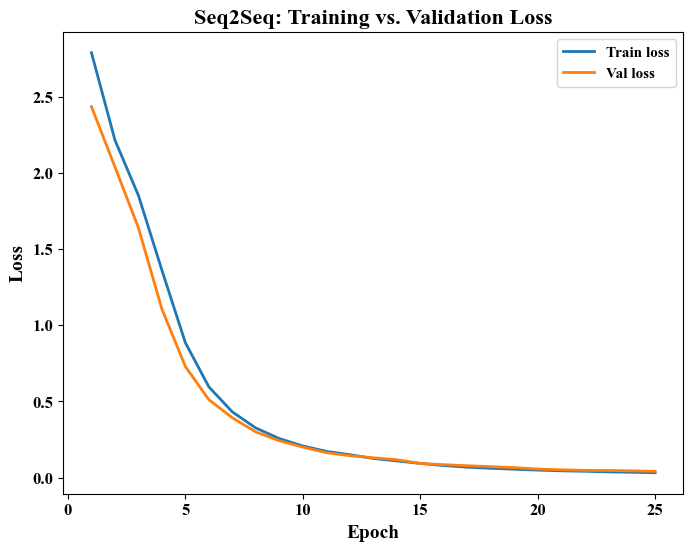

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


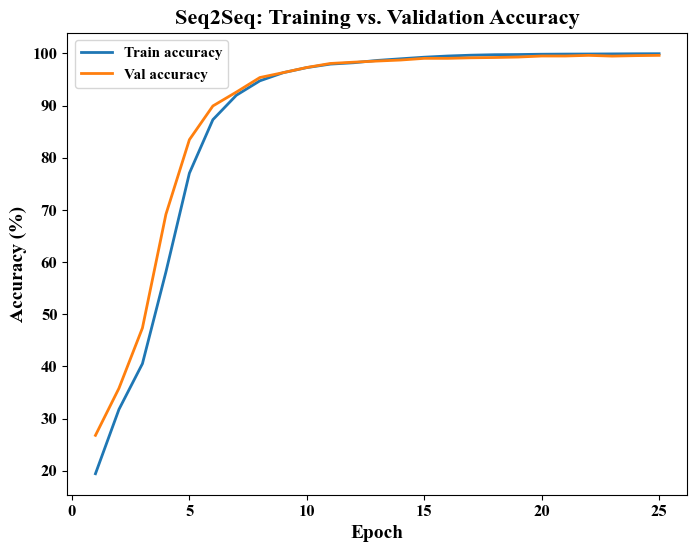

In [35]:
def train_seq2seq_with_checkpoint(name, epochs=25, batch_size=64, force=False):
    paths = ckpt_paths(name)

    if os.path.exists(paths["done"]) and not force:
        print(f"[{name}] Found completed checkpoint — loading without retraining.")
        model = keras.models.load_model(paths["model"])
        history = load_json(paths["history"])
        elapsed = load_json(paths["time"], {"seconds": 0.0})["seconds"]
        return model, history, elapsed

    if force:
        for p in paths.values():
            if os.path.exists(p):
                os.remove(p)

    initial_epoch = 0
    if os.path.exists(paths["model"]) and os.path.exists(paths["log"]):
        print(f"[{name}] Resuming from checkpoint...")
        model = keras.models.load_model(paths["model"])
        prev_log = pd.read_csv(paths["log"])
        initial_epoch = int(prev_log["epoch"].max()) + 1 if len(prev_log) else 0
    else:
        print(f"[{name}] Starting fresh...")
        model = seq2seq_train_model

    cbs = [
        callbacks.ModelCheckpoint(paths["model"], save_freq="epoch", save_best_only=False),
        callbacks.CSVLogger(paths["log"], append=os.path.exists(paths["log"])),
    ]

    start = time.time()
    model.fit(
        [enc_in_tr, dec_in_tr], dec_tgt_tr,
        validation_data=([enc_in_va, dec_in_va], dec_tgt_va),
        epochs=epochs, initial_epoch=initial_epoch, batch_size=batch_size,
        callbacks=cbs, verbose=1,
    )
    run_elapsed = time.time() - start
    prev_elapsed = load_json(paths["time"], {"seconds": 0.0})["seconds"]
    total_elapsed = prev_elapsed + run_elapsed
    save_json({"seconds": total_elapsed}, paths["time"])

    history = pd.read_csv(paths["log"]).to_dict(orient="list")
    save_json(history, paths["history"])
    Path(paths["done"]).touch()
    return model, history, total_elapsed

seq2seq_model, seq2seq_history, seq2seq_time = train_seq2seq_with_checkpoint("seq2seq_reversal")
plot_curves(seq2seq_history, "Seq2Seq")

## 20. Seq2Seq Evaluation — Token Accuracy, Sequence Accuracy, and Example Predictions

In [36]:
def greedy_decode(input_seq, max_len=SEQ2SEQ_LEN + 1):
    states = seq2seq_encoder_infer.predict(input_seq[None, :], verbose=0)
    h, c = states
    token = np.array([[SOS_TOKEN]])
    decoded = []
    for _ in range(max_len):
        probs, h, c = seq2seq_decoder_infer.predict([token, h, c], verbose=0)
        next_token = int(np.argmax(probs[0, -1, :]))
        if next_token == EOS_TOKEN:
            break
        decoded.append(next_token)
        token = np.array([[next_token]])
    return decoded

def evaluate_seq2seq(enc_in, force=False):
    def _compute():
        token_correct, token_total, seq_correct = 0, 0, 0
        predictions = []
        for i in range(len(enc_in)):
            true_seq = list(enc_in[i][::-1])
            pred_seq = greedy_decode(enc_in[i])
            predictions.append(pred_seq)

            L = min(len(true_seq), len(pred_seq))
            token_correct += sum(int(a == b) for a, b in zip(true_seq[:L], pred_seq[:L]))
            token_total += len(true_seq)
            seq_correct += int(pred_seq == true_seq)
        return {
            "token_accuracy": token_correct / token_total,
            "sequence_accuracy": seq_correct / len(enc_in),
            "n_eval": len(enc_in),
        }
    return cached_result("seq2seq_eval", _compute, force=force)

# Evaluate on a subset of the test set for speed (greedy decoding is sequential / not batched);
# increase this if you want a tighter estimate.
EVAL_SUBSET = min(300, len(enc_in_te))
seq2seq_metrics = evaluate_seq2seq(enc_in_te[:EVAL_SUBSET])
print(f"Token accuracy:    {seq2seq_metrics['token_accuracy']*100:.2f}%")
print(f"Sequence accuracy: {seq2seq_metrics['sequence_accuracy']*100:.2f}%")
print(f"(evaluated on {seq2seq_metrics['n_eval']} test sequences)")

Token accuracy:    98.50%
Sequence accuracy: 97.67%
(evaluated on 300 test sequences)


In [37]:
print(f"{'Input':<20}{'Predicted Output':<20}{'Correct?'}")
example_rows = []
for i in range(5):
    inp = list(enc_in_te[i])
    pred = greedy_decode(enc_in_te[i])
    true = inp[::-1]
    correct = "Yes" if pred == true else "No"
    print(f"{str(inp):<20}{str(pred):<20}{correct}")
    example_rows.append({"Input Sequence": inp, "Predicted Output": pred, "Correct": correct})

pd.DataFrame(example_rows).to_csv(f"{RESULTS_DIR}/seq2seq_examples.csv", index=False)

Input               Predicted Output    Correct?
[np.int32(15), np.int32(15), np.int32(18), np.int32(14), np.int32(1), np.int32(10)][10, 1, 14, 15, 18, 18]No
[np.int32(15), np.int32(18), np.int32(7), np.int32(18), np.int32(16), np.int32(2)][2, 16, 18, 7, 18, 15]Yes
[np.int32(12), np.int32(19), np.int32(12), np.int32(13), np.int32(1), np.int32(19)][19, 1, 13, 12, 19, 12]Yes
[np.int32(4), np.int32(17), np.int32(19), np.int32(14), np.int32(10), np.int32(6)][6, 10, 14, 19, 17, 4]Yes
[np.int32(17), np.int32(10), np.int32(2), np.int32(9), np.int32(2), np.int32(18)][18, 2, 9, 2, 10, 17]Yes


**Inference — why can sequence-level accuracy be substantially lower than token accuracy even when most
individual tokens are predicted correctly?** (Hint: a sequence is only "correct" if *every* token matches;
with `L` tokens each independently correct with probability `p`, the expected sequence accuracy is
roughly `p^L` under a naive independence assumption — a small per-token error rate compounds multiplicatively.)

## 21. Consolidated Results

In [38]:
consolidated = pd.concat([
    results_df.assign(Task="HAR sequence classification"),
    video_results_df.assign(Task="Video action recognition"),
], ignore_index=True)
consolidated = consolidated[["Task", "model", "Accuracy (%)", "Macro Precision (%)",
                              "Macro Recall (%)", "Macro F1 (%)", "Parameters", "Training Time (s)"]]
consolidated.to_csv(f"{RESULTS_DIR}/consolidated_results.csv", index=False)
consolidated

,Task,model,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
0,HAR sequence classification,har_rnn,69.290804,68.987431,68.490207,68.024700,1974,46.137621
1,HAR sequence classification,har_lstm,89.107567,89.108093,89.302456,89.163170,6006,95.899653
2,HAR sequence classification,har_gru,89.548694,89.547363,89.699375,89.497081,4758,121.602311
3,Video action recognition,video_cnn_lstm,100.000000,100.000000,100.000000,100.000000,168229,7.910281
4,Video action recognition,video_cnn_gru,100.000000,100.000000,100.000000,100.000000,126309,8.081426


In [39]:
seq2seq_table = pd.DataFrame([{
    "Task": "Sequence-to-sequence reversal",
    "Token Accuracy (%)": seq2seq_metrics["token_accuracy"] * 100,
    "Sequence Accuracy (%)": seq2seq_metrics["sequence_accuracy"] * 100,
    "Final Train Loss": seq2seq_history["loss"][-1],
    "Final Val Loss": seq2seq_history["val_loss"][-1],
}])
seq2seq_table.to_csv(f"{RESULTS_DIR}/seq2seq_results.csv", index=False)
seq2seq_table

,Task,Token Accuracy (%),Sequence Accuracy (%),Final Train Loss,Final Val Loss
0,Sequence-to-sequence reversal,98.5,97.666667,0.031467,0.040368


## 22. Discussion Questions

All 25 discussion questions from the handout (Section 27) should be answered in your written report,
grounded in what you actually observed above — e.g. your specific accuracy numbers, your specific
confusion-matrix pairs, and your specific sequence-length F1 trend, rather than generic textbook answers.
The theory sections above (Section 3 for RNN/BPTT, Section 10 for LSTM, Section 11 for GRU, Section 18
for encoder-decoder) contain the conceptual scaffolding for questions 1-14 and 18-23; questions 15-17 and
24-25 should be answered directly from your Section 9, 11, and 20 results.

## 23. Reproducibility Checklist

- [x] All random seeds fixed (`SEED = 42`) for NumPy and TensorFlow.
- [x] Same train/val/test protocol and normalization statistics (fit on train only) used across RNN/LSTM/GRU.
- [x] Every training run (HAR × 3 models, sequence-length sweep × 9 runs, video × 2 models, seq2seq × 1)
      is checkpointed under `checkpoints/` and safely resumable.
- [x] All figures saved to `images/` as both `.eps` (600 dpi, publication) and `.png` (inline preview).
- [x] All numeric results saved to `results/` as CSV for direct inclusion in your report tables.
- [ ] If using the synthetic video fallback, re-run Section 12 onward with real UCF101 clips before
      treating video numbers as final.